# Healthcare Appointment Data Analysis using Python Pandas

## Project Overview
This project analyzes a synthetic healthcare appointment dataset using Python, Pandas, and Matplotlib.

The main goal of this project is to clean the dataset, analyze appointment patterns, and visualize key healthcare service indicators such as appointment status, department visits, city-wise appointments, monthly trends, treatment cost, and patient satisfaction.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab

## Dataset Note
This project uses a synthetic sample dataset created for learning and portfolio demonstration.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

In [ ]:
np.random.seed(42)

n = 300

departments = ["General Medicine", "Cardiology", "Orthopedics", "Pediatrics", "Gynecology", "Dermatology"]
cities = ["Tokyo", "Chiba", "Yokohama", "Osaka", "Saitama", "Kyoto"]
genders = ["Male", "Female"]
statuses = ["Completed", "Cancelled", "No-show"]
payment_methods = ["Cash", "Credit Card", "Insurance"]

data = {
    "Appointment_ID": range(1001, 1001 + n),
    "Appointment_Date": pd.date_range(start="2024-01-01", periods=n, freq="D"),
    "Patient_Age": np.random.randint(5, 80, size=n),
    "Gender": np.random.choice(genders, size=n),
    "Department": np.random.choice(departments, size=n),
    "City": np.random.choice(cities, size=n),
    "Appointment_Status": np.random.choice(statuses, size=n, p=[0.72, 0.15, 0.13]),
    "Treatment_Cost": np.random.randint(3000, 50000, size=n),
    "Payment_Method": np.random.choice(payment_methods, size=n),
    "Satisfaction_Score": np.random.randint(1, 6, size=n)
}

df = pd.DataFrame(data)

# Add some intentional missing values and duplicate rows for cleaning practice
df.loc[5, "Treatment_Cost"] = np.nan
df.loc[15, "Satisfaction_Score"] = np.nan
df.loc[25, "City"] = np.nan

df = pd.concat([df, df.iloc[[10, 20]]], ignore_index=True)

df.head()

,Appointment_ID,Appointment_Date,Patient_Age,Gender,Department,City,Appointment_Status,Treatment_Cost,Payment_Method,Satisfaction_Score
0,1001,2024-01-01,56,Female,Dermatology,Tokyo,Completed,21297.0,Credit Card,5.0
1,1002,2024-01-02,19,Male,Pediatrics,Saitama,Completed,33448.0,Insurance,4.0
2,1003,2024-01-03,76,Female,Orthopedics,Tokyo,Completed,29172.0,Cash,1.0
3,1004,2024-01-04,65,Male,Cardiology,Osaka,Cancelled,45874.0,Cash,4.0
4,1005,2024-01-05,25,Male,Gynecology,Chiba,No-show,10657.0,Cash,3.0


In [ ]:
# Check dataset size
print("Rows and columns:", df.shape)

# Check column names and data types
df.info()

Rows and columns: (302, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Appointment_ID      302 non-null    int64         
 1   Appointment_Date    302 non-null    datetime64[ns]
 2   Patient_Age         302 non-null    int64         
 3   Gender              302 non-null    object        
 4   Department          302 non-null    object        
 5   City                301 non-null    object        
 6   Appointment_Status  302 non-null    object        
 7   Treatment_Cost      301 non-null    float64       
 8   Payment_Method      302 non-null    object        
 9   Satisfaction_Score  301 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 23.7+ KB


In [ ]:
# Check missing values
df.isnull().sum()

,0
Appointment_ID,0
Appointment_Date,0
Patient_Age,0
Gender,0
Department,0
City,1
Appointment_Status,0
Treatment_Cost,1
Payment_Method,0
Satisfaction_Score,1


In [ ]:
# Check duplicate rows
df.duplicated().sum()

np.int64(2)

In [ ]:
# Summary statistics
df.describe()

,Appointment_ID,Appointment_Date,Patient_Age,Treatment_Cost,Satisfaction_Score
count,302.000000,302,302.000000,301.000000,301.000000
mean,1149.609272,2024-05-28 14:37:21.059602688,41.397351,26538.920266,3.099668
min,1001.000000,2024-01-01 00:00:00,5.000000,3105.000000,1.000000
25%,1074.250000,2024-03-14 06:00:00,23.000000,14722.000000,2.000000
50%,1149.500000,2024-05-28 12:00:00,41.000000,26821.000000,3.000000
75%,1224.750000,2024-08-11 18:00:00,61.000000,36742.000000,4.000000
max,1300.000000,2024-10-26 00:00:00,79.000000,49824.000000,5.000000
std,87.146836,NaN,21.893909,13143.445189,1.413046


In [ ]:
# Create a copy of the original dataset before cleaning
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Fill missing City values with "Unknown"
df_clean["City"] = df_clean["City"].fillna("Unknown")

# Fill missing Treatment_Cost with median value
df_clean["Treatment_Cost"] = df_clean["Treatment_Cost"].fillna(df_clean["Treatment_Cost"].median())

# Fill missing Satisfaction_Score with median value
df_clean["Satisfaction_Score"] = df_clean["Satisfaction_Score"].fillna(df_clean["Satisfaction_Score"].median())

# Check missing values after cleaning
df_clean.isnull().sum()

,0
Appointment_ID,0
Appointment_Date,0
Patient_Age,0
Gender,0
Department,0
City,0
Appointment_Status,0
Treatment_Cost,0
Payment_Method,0
Satisfaction_Score,0


In [ ]:
# Compare original and cleaned dataset shape
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

# Check duplicate rows after cleaning
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())

Original dataset shape: (302, 10)
Cleaned dataset shape: (300, 10)
Duplicate rows after cleaning: 0


In [ ]:
# Convert Appointment_Date to datetime format
df_clean["Appointment_Date"] = pd.to_datetime(df_clean["Appointment_Date"])

# Create Month column
df_clean["Month"] = df_clean["Appointment_Date"].dt.month_name()

# Create Age Group column
def age_group(age):
    if age < 18:
        return "0-17"
    elif age < 35:
        return "18-34"
    elif age < 50:
        return "35-49"
    elif age < 65:
        return "50-64"
    else:
        return "65+"

df_clean["Age_Group"] = df_clean["Patient_Age"].apply(age_group)

# Show first 5 rows after creating new columns
df_clean.head()

,Appointment_ID,Appointment_Date,Patient_Age,Gender,Department,City,Appointment_Status,Treatment_Cost,Payment_Method,Satisfaction_Score,Month,Age_Group
0,1001,2024-01-01,56,Female,Dermatology,Tokyo,Completed,21297.0,Credit Card,5.0,January,50-64
1,1002,2024-01-02,19,Male,Pediatrics,Saitama,Completed,33448.0,Insurance,4.0,January,18-34
2,1003,2024-01-03,76,Female,Orthopedics,Tokyo,Completed,29172.0,Cash,1.0,January,65+
3,1004,2024-01-04,65,Male,Cardiology,Osaka,Cancelled,45874.0,Cash,4.0,January,65+
4,1005,2024-01-05,25,Male,Gynecology,Chiba,No-show,10657.0,Cash,3.0,January,18-34


In [ ]:
# Check updated dataset
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Appointment_ID      300 non-null    int64         
 1   Appointment_Date    300 non-null    datetime64[ns]
 2   Patient_Age         300 non-null    int64         
 3   Gender              300 non-null    object        
 4   Department          300 non-null    object        
 5   City                300 non-null    object        
 6   Appointment_Status  300 non-null    object        
 7   Treatment_Cost      300 non-null    float64       
 8   Payment_Method      300 non-null    object        
 9   Satisfaction_Score  300 non-null    float64       
 10  Month               300 non-null    object        
 11  Age_Group           300 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(7)
memory usage: 30.5+ KB


In [ ]:
# KPI Summary

total_appointments = df_clean["Appointment_ID"].nunique()
total_treatment_cost = df_clean["Treatment_Cost"].sum()
average_treatment_cost = df_clean["Treatment_Cost"].mean()
average_satisfaction = df_clean["Satisfaction_Score"].mean()

completed_rate = (
    df_clean["Appointment_Status"].value_counts(normalize=True)["Completed"] * 100
)

print("Total Appointments:", total_appointments)
print("Total Treatment Cost:", round(total_treatment_cost, 2))
print("Average Treatment Cost:", round(average_treatment_cost, 2))
print("Average Satisfaction Score:", round(average_satisfaction, 2))
print("Completed Appointment Rate:", round(completed_rate, 2), "%")

Total Appointments: 300
Total Treatment Cost: 7955123.0
Average Treatment Cost: 26517.08
Average Satisfaction Score: 3.1
Completed Appointment Rate: 69.33 %


In [ ]:
# Appointments by status
appointments_by_status = df_clean["Appointment_Status"].value_counts()

appointments_by_status

,count
Appointment_Status,
Completed,208
Cancelled,54
No-show,38


In [ ]:
# Appointments by department
appointments_by_department = df_clean["Department"].value_counts()

appointments_by_department

,count
Department,
Gynecology,64
Cardiology,51
General Medicine,48
Orthopedics,47
Pediatrics,45
Dermatology,45


In [ ]:
# Appointments by city
appointments_by_city = df_clean["City"].value_counts()

appointments_by_city

,count
City,
Kyoto,59
Tokyo,50
Osaka,49
Yokohama,48
Saitama,47
Chiba,46
Unknown,1


In [ ]:
# Total treatment cost by department
cost_by_department = df_clean.groupby("Department")["Treatment_Cost"].sum().sort_values(ascending=False)

cost_by_department

,Treatment_Cost
Department,
Gynecology,1691066.0
Cardiology,1319283.0
Orthopedics,1301110.0
General Medicine,1277232.0
Dermatology,1201709.0
Pediatrics,1164723.0


In [ ]:
# Average satisfaction score by department
satisfaction_by_department = df_clean.groupby("Department")["Satisfaction_Score"].mean().sort_values(ascending=False)

satisfaction_by_department

,Satisfaction_Score
Department,
Orthopedics,3.489362
General Medicine,3.125000
Pediatrics,3.111111
Gynecology,3.046875
Dermatology,3.000000
Cardiology,2.862745


In [ ]:
# Chart style setup

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 10

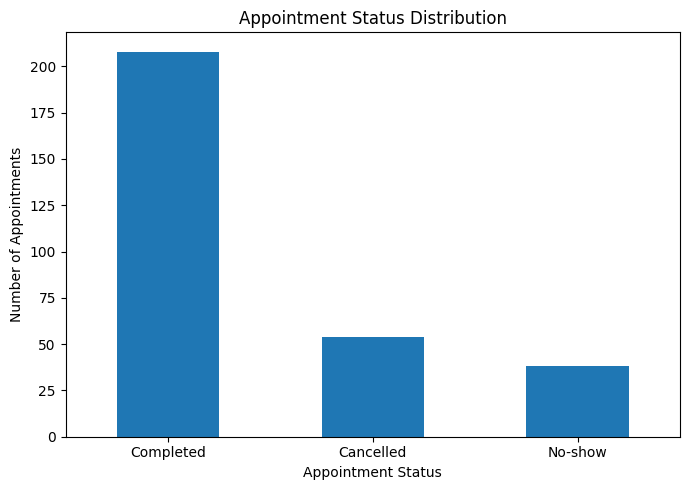

In [ ]:
# Appointment status distribution

appointments_by_status = df_clean["Appointment_Status"].value_counts()

plt.figure(figsize=(7, 5))
appointments_by_status.plot(kind="bar")

plt.title("Appointment Status Distribution")
plt.xlabel("Appointment Status")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

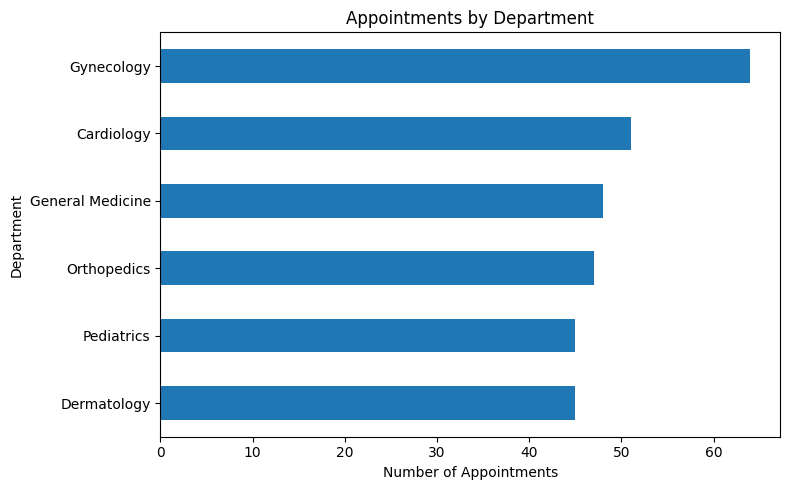

In [ ]:
# Appointments by department

appointments_by_department = df_clean["Department"].value_counts()

plt.figure(figsize=(8, 5))
appointments_by_department.plot(kind="barh")

plt.title("Appointments by Department")
plt.xlabel("Number of Appointments")
plt.ylabel("Department")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

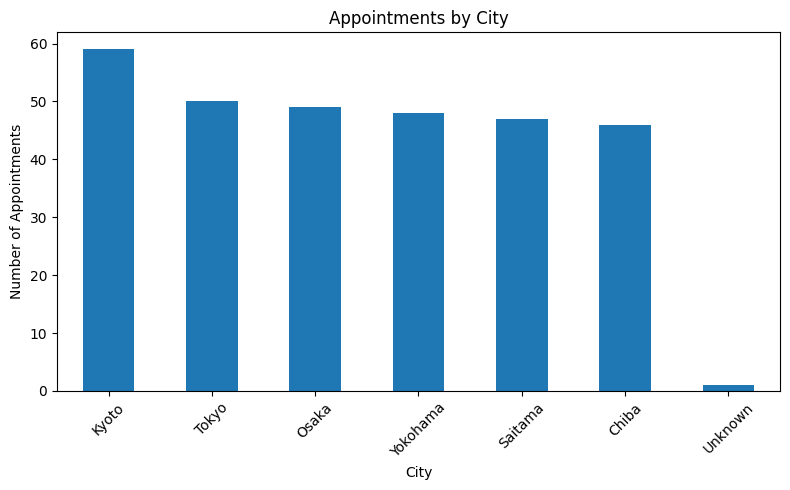

In [ ]:
# Appointments by city

appointments_by_city = df_clean["City"].value_counts()

plt.figure(figsize=(8, 5))
appointments_by_city.plot(kind="bar")

plt.title("Appointments by City")
plt.xlabel("City")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

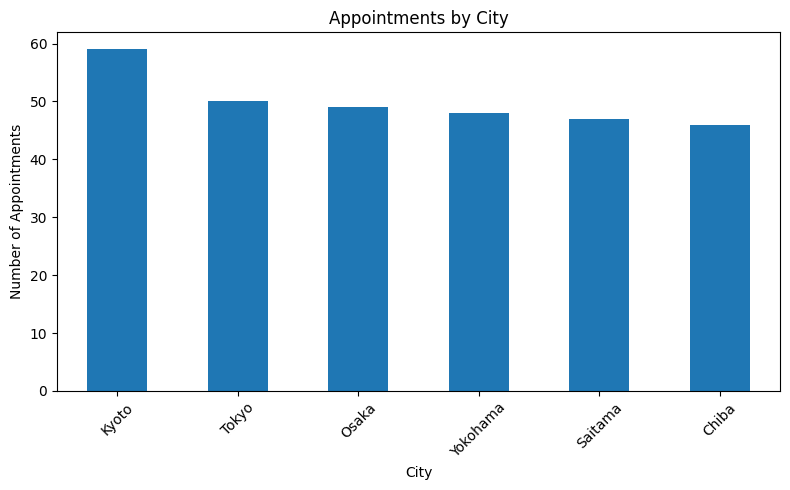

In [ ]:
# Appointments by city excluding Unknown

appointments_by_city = df_clean[df_clean["City"] != "Unknown"]["City"].value_counts()

plt.figure(figsize=(8, 5))
appointments_by_city.plot(kind="bar")

plt.title("Appointments by City")
plt.xlabel("City")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

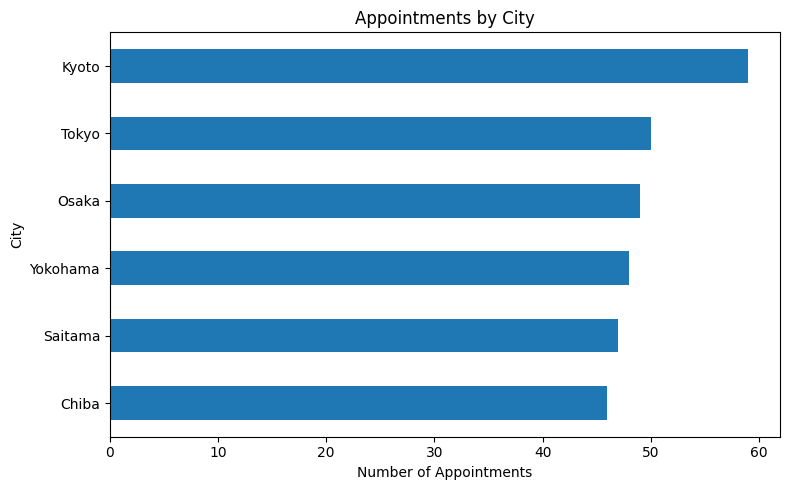

In [ ]:
# Appointments by city excluding Unknown - horizontal version

appointments_by_city = df_clean[df_clean["City"] != "Unknown"]["City"].value_counts()

plt.figure(figsize=(8, 5))
appointments_by_city.plot(kind="barh")

plt.title("Appointments by City")
plt.xlabel("Number of Appointments")
plt.ylabel("City")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

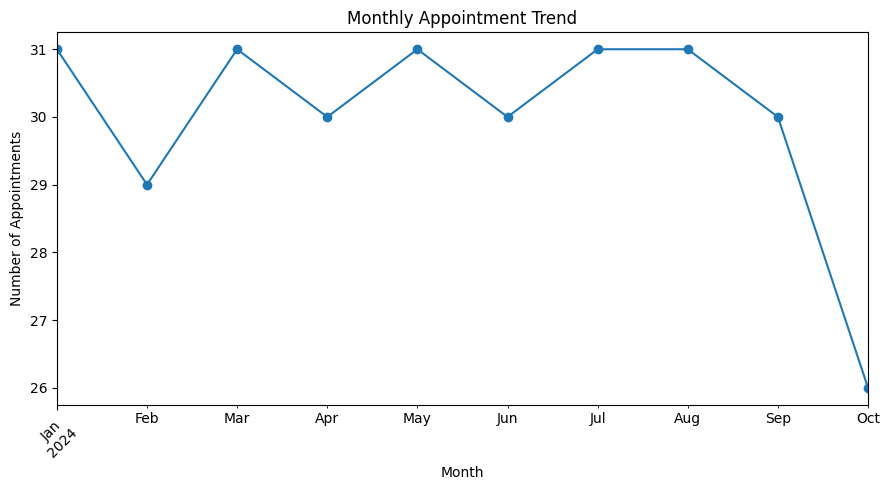

In [ ]:
# Monthly appointment trend

monthly_trend = df_clean.groupby(
    df_clean["Appointment_Date"].dt.to_period("M")
)["Appointment_ID"].count()

plt.figure(figsize=(9, 5))
monthly_trend.plot(kind="line", marker="o")

plt.title("Monthly Appointment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

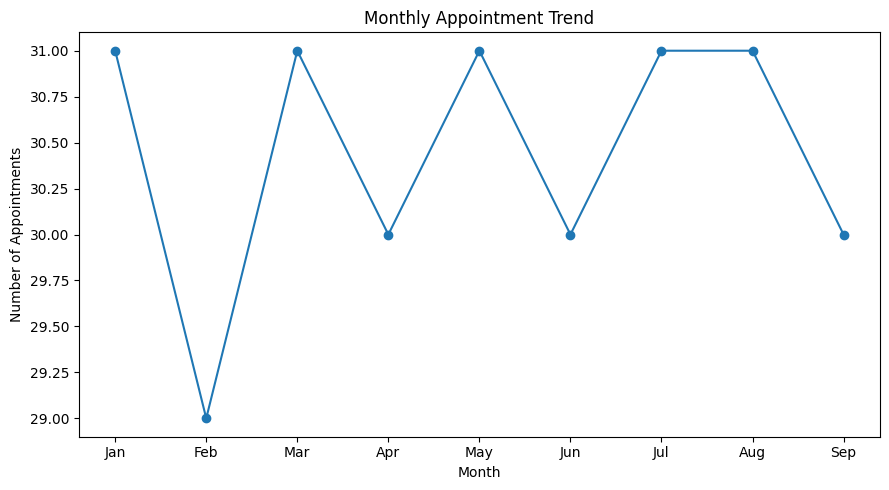

In [ ]:
# Monthly appointment trend excluding partial October data

df_complete_months = df_clean[df_clean["Appointment_Date"] < "2024-10-01"]

monthly_trend = df_complete_months.groupby(
    df_complete_months["Appointment_Date"].dt.strftime("%b")
)["Appointment_ID"].count()

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep"]
monthly_trend = monthly_trend.reindex(month_order)

plt.figure(figsize=(9, 5))
monthly_trend.plot(kind="line", marker="o")

plt.title("Monthly Appointment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

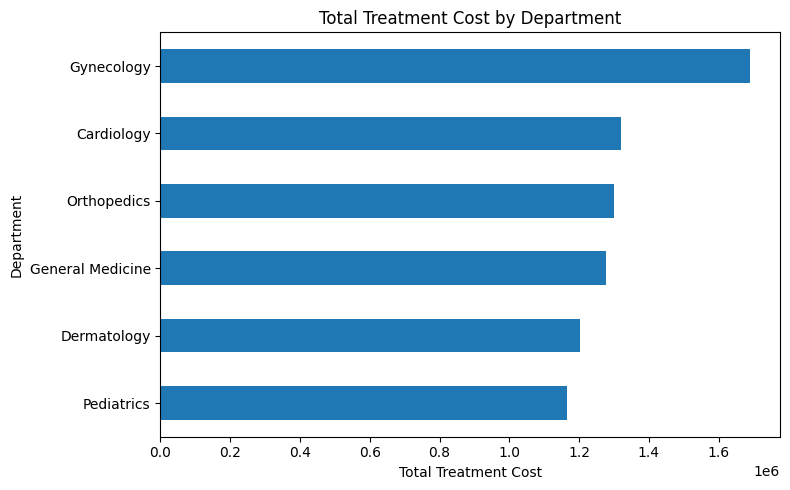

In [ ]:
# Total treatment cost by department

cost_by_department = df_clean.groupby("Department")["Treatment_Cost"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
cost_by_department.plot(kind="barh")

plt.title("Total Treatment Cost by Department")
plt.xlabel("Total Treatment Cost")
plt.ylabel("Department")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

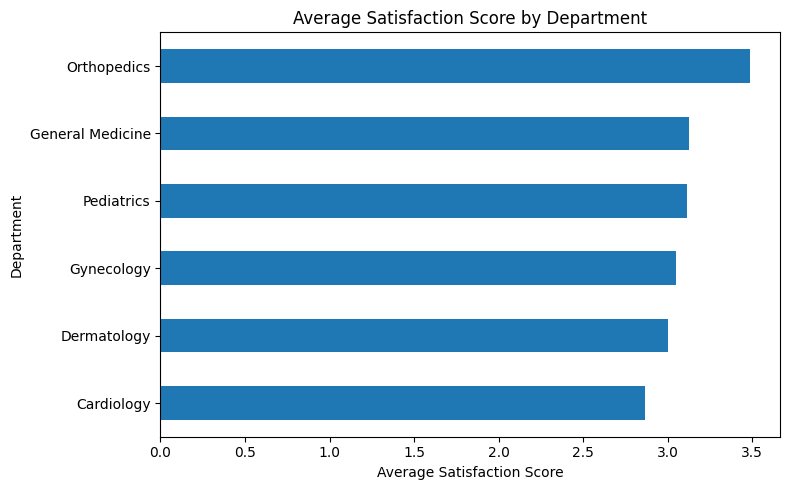

In [ ]:
# Average satisfaction score by department

satisfaction_by_department = df_clean.groupby("Department")["Satisfaction_Score"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
satisfaction_by_department.plot(kind="barh")

plt.title("Average Satisfaction Score by Department")
plt.xlabel("Average Satisfaction Score")
plt.ylabel("Department")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Final project summary

print("Final Project Summary")
print("----------------------")
print("Total appointments analyzed:", total_appointments)
print("Total treatment cost:", round(total_treatment_cost, 2))
print("Average treatment cost:", round(average_treatment_cost, 2))
print("Average satisfaction score:", round(average_satisfaction, 2))
print("Completed appointment rate:", round(completed_rate, 2), "%")

Final Project Summary
----------------------
Total appointments analyzed: 300
Total treatment cost: 7955123.0
Average treatment cost: 26517.08
Average satisfaction score: 3.1
Completed appointment rate: 69.33 %


In [ ]:
# Key insights from the analysis

print("Key Insights")
print("------------")
print("1. Completed appointments were the highest compared with cancelled and no-show appointments.")
print("2. Gynecology had the highest number of appointments among all departments.")
print("3. Kyoto had the highest number of patient visits among the listed cities.")
print("4. Gynecology generated the highest total treatment cost.")
print("5. Orthopedics had the highest average satisfaction score.")
print("6. October data was partial, so the monthly trend should be interpreted carefully.")

Key Insights
------------
1. Completed appointments were the highest compared with cancelled and no-show appointments.
2. Gynecology had the highest number of appointments among all departments.
3. Kyoto had the highest number of patient visits among the listed cities.
4. Gynecology generated the highest total treatment cost.
5. Orthopedics had the highest average satisfaction score.
6. October data was partial, so the monthly trend should be interpreted carefully.


## Conclusion

This project demonstrated how Python Pandas can be used to clean, analyze, and visualize healthcare appointment data.  
The analysis identified appointment patterns by status, department, city, month, treatment cost, and patient satisfaction.

The project also showed basic data cleaning steps, including duplicate removal, missing value handling, feature engineering, groupby analysis, and data visualization using Matplotlib.

Note: This project uses a synthetic sample dataset created for learning and portfolio demonstration.